In [2]:
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) == 2, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.10.0+cpu
torchvision version: 0.25.0+cpu


In [3]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms
from torchinfo import summary
from going_modular.going_modular import data_setup, engine
from helper_functions import download_data, set_seeds, plot_loss_curves


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [5]:
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] data\pizza_steak_sushi directory exists, skipping download.


WindowsPath('data/pizza_steak_sushi')

In [6]:
train_dir = image_path / 'train'
test_dir = image_path / 'test'

In [7]:
IMG_SIZE = 224

manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(manual_transforms)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [8]:
BATCH_SIZE = 32

train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir = train_dir,
    test_dir = test_dir,
    transform = manual_transforms,
    batch_size = BATCH_SIZE
)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x2827841e540>,
 ['pizza', 'steak', 'sushi'])

In [9]:
image_batch, label_batch = next(iter(train_dataloader))

image, label = image_batch[0], label_batch[0]

image.shape, label

c:\Users\prave\PyTorch\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


(torch.Size([3, 224, 224]), tensor(1))

(-0.5, 223.5, 223.5, -0.5)

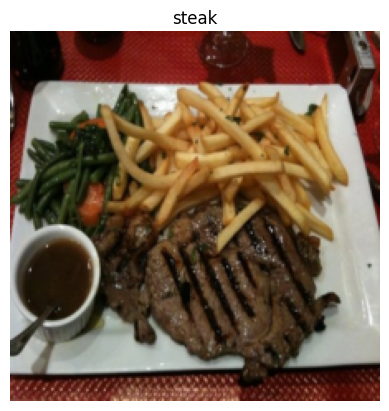

In [10]:
plt.imshow(image.permute(1, 2, 0)) 
plt.title(class_names[label])
plt.axis(False)

In [11]:
height = 224
width = 224
color_channels = 3
patch_size = 16

number_of_patches = int((height * width) / patch_size**2)
print(f"Number of patches (N) with image height (H={height}), width (W={width}) and patch size (P={patch_size}): {number_of_patches}")

Number of patches (N) with image height (H=224), width (W=224) and patch size (P=16): 196


In [12]:
embedding_layer_input_shape = (height, width, color_channels)
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Input shape (single 2D image): {embedding_layer_input_shape}")
print(f"Output shape (single 2D image flattened into patches): {embedding_layer_output_shape}")


Input shape (single 2D image): (224, 224, 3)
Output shape (single 2D image flattened into patches): (196, 768)


(-0.5, 223.5, 223.5, -0.5)

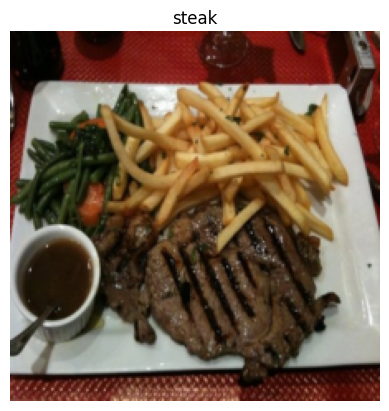

In [13]:
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False)

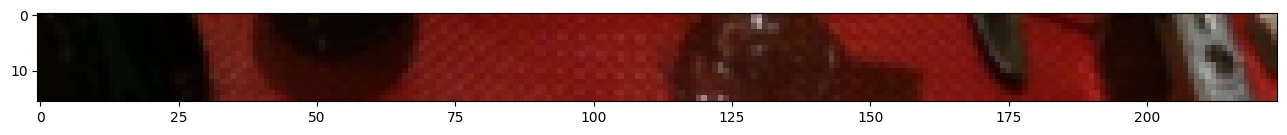

In [14]:
image_permuted = image.permute(1, 2, 0)

patch_size = 16
plt.figure(figsize = (patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :])

Number of patches per row: 14.0
Patch size: 16 pixels x 16 pixels


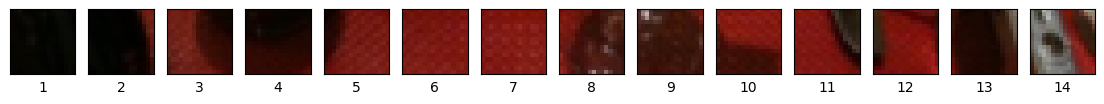

In [15]:
img_size= 224
patch_size = 16
num_patches = img_size/patch_size

assert img_size % patch_size == 0
print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

fig, axs = plt.subplots(nrows=1,
                        ncols=img_size // patch_size, 
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

for i, patch in enumerate(range(0, img_size, patch_size)):
    axs[i].imshow(image_permuted[:patch_size, patch:patch+patch_size, :]); 
    axs[i].set_xlabel(i+1) 
    axs[i].set_xticks([])
    axs[i].set_yticks([])

Number of patches per row: 14.0        
Number of patches per column: 14.0        
Total patches: 196.0        
Patch size: 16 pixels x 16 pixels


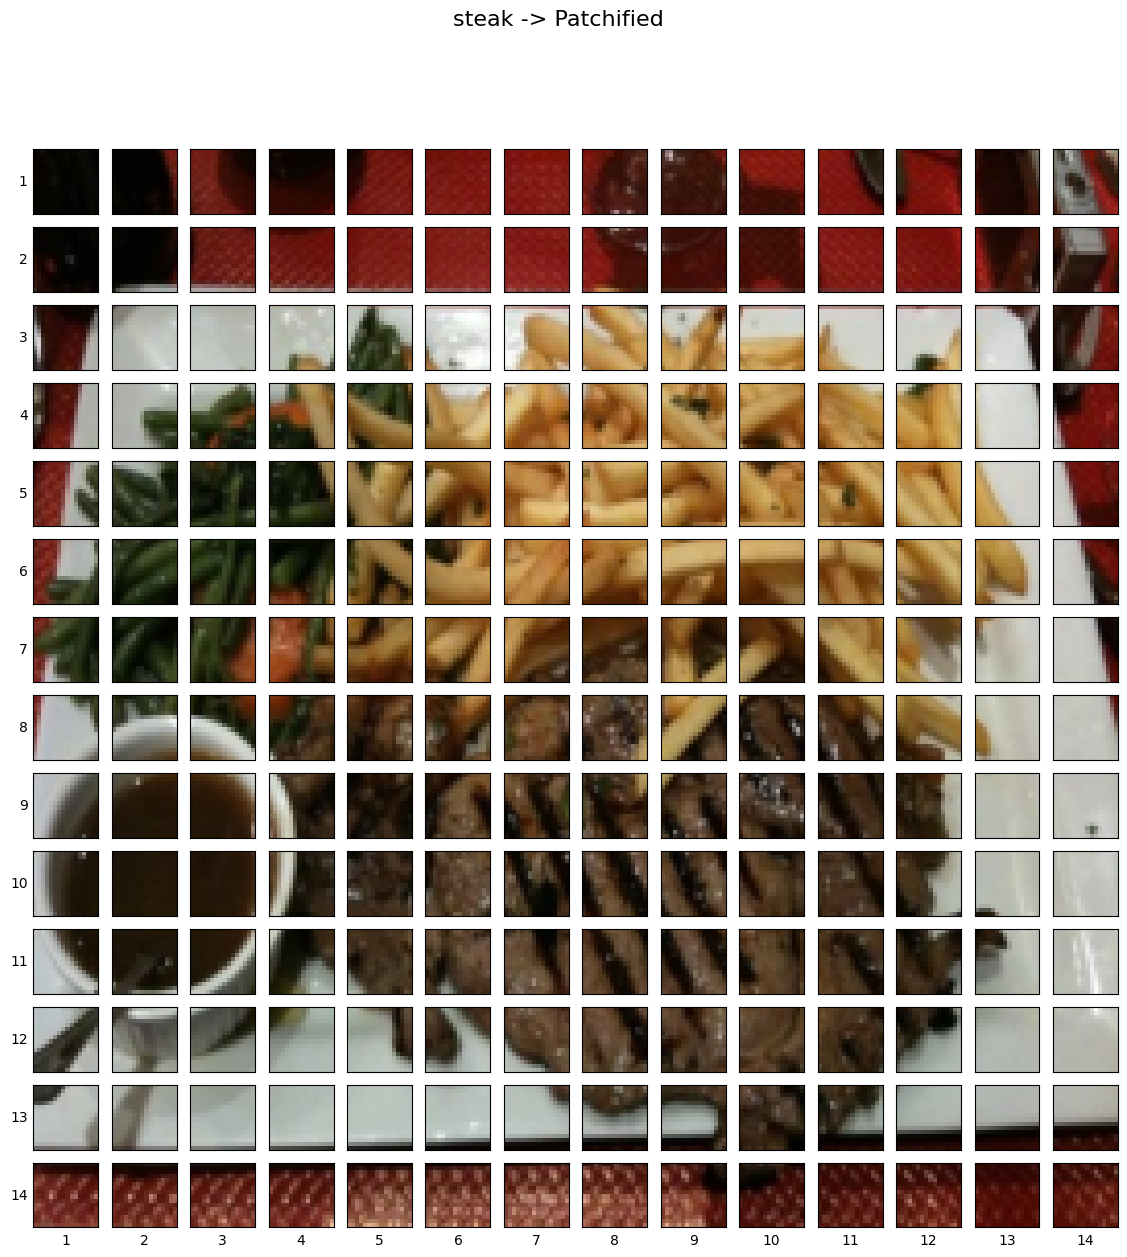

In [16]:
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")


fig, axs = plt.subplots(nrows=img_size // patch_size, #
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

for i, patch_height in enumerate(range(0, img_size, patch_size)): 
    for j, patch_width in enumerate(range(0, img_size, patch_size)): 

        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size,
                                        patch_width:patch_width+patch_size,
                                        :]) 

        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

In [17]:
from torch import nn

patch_size = 16

conv2d = nn.Conv2d(in_channels = 3,
out_channels = 768,
kernel_size = patch_size,
stride = patch_size,
padding = 0)

(-0.5, 223.5, 223.5, -0.5)

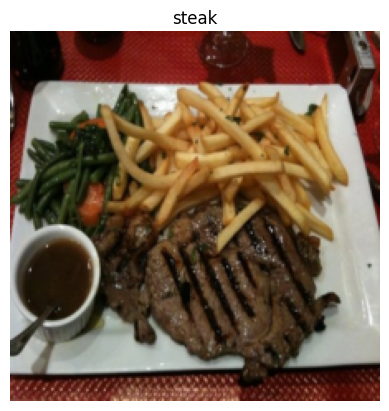

In [18]:
import matplotlib.pyplot as plt

plt.imshow(image.permute(1, 2, 0)) 
plt.title(class_names[label])
plt.axis(False)

In [19]:
image_out_of_conv = conv2d(image.unsqueeze(0)) 
print(image_out_of_conv.shape)

torch.Size([1, 768, 14, 14])


[516, 421, 738, 635, 257]


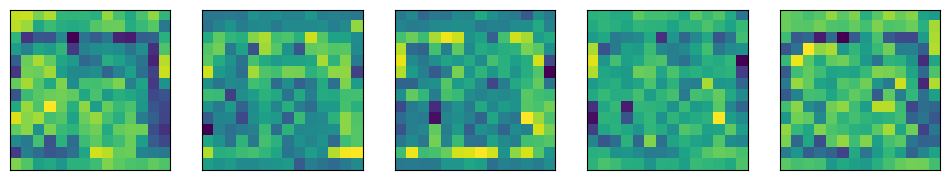

In [20]:
import random
random_indexes = random.sample(range(0, 758), k = 5)
print(random_indexes)

fig, axs = plt.subplots(nrows = 1, ncols = 5, figsize = (12,12))

for i ,idx in enumerate(random_indexes):
    image_conv_feature_map = image_out_of_conv[:, idx, :, :]
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticklabels = [], yticklabels = [], xticks = [], yticks = [])

In [21]:
single_feature_map = image_out_of_conv[:, 0, :, :]
single_feature_map, single_feature_map.requires_grad

(tensor([[[ 4.1293e-02, -6.0372e-02,  1.0035e-01,  1.8534e-02, -7.0364e-02,
           -5.8982e-02, -6.6258e-02,  2.2028e-03, -1.7886e-02, -1.1571e-01,
            3.3370e-02, -1.0551e-02, -5.9646e-02,  3.4527e-01],
          [ 3.7433e-02,  8.4490e-02, -4.3280e-02, -1.1699e-02, -4.0488e-02,
           -4.8167e-02, -4.3236e-02, -2.0787e-02, -3.9159e-02, -5.2851e-02,
           -7.9678e-02, -1.0236e-01, -3.0788e-02, -1.2459e-02],
          [ 1.6760e-01,  5.2397e-01,  5.1992e-01,  4.6641e-01, -1.6359e-01,
            5.5512e-01,  3.0822e-01,  9.0717e-03,  3.4890e-01,  3.1181e-01,
            4.4054e-01,  4.1492e-01,  6.3083e-01, -9.3785e-02],
          [ 1.4313e-02,  4.4222e-01,  7.0303e-02, -1.4323e-01,  1.7386e-01,
            7.8187e-02,  1.1862e-01, -1.2908e-01, -6.9014e-03, -9.5015e-03,
            3.9930e-02, -5.0471e-02,  6.4934e-01, -1.4136e-01],
          [ 7.0483e-02, -1.0762e-01, -5.8000e-03,  2.1284e-02,  1.2735e-01,
            1.7635e-01,  5.3567e-02,  9.5435e-02, -1.2939e-0

In [22]:
print(f"Current tensor shape: {image_out_of_conv.shape} -> [batch, embedding_dim, feature_map_height, feature_map_width]")

Current tensor shape: torch.Size([1, 768, 14, 14]) -> [batch, embedding_dim, feature_map_height, feature_map_width]


In [23]:
flatten = nn.Flatten(start_dim = 2,
end_dim = 3)

Original image shape: torch.Size([3, 224, 224])
Image feature map shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


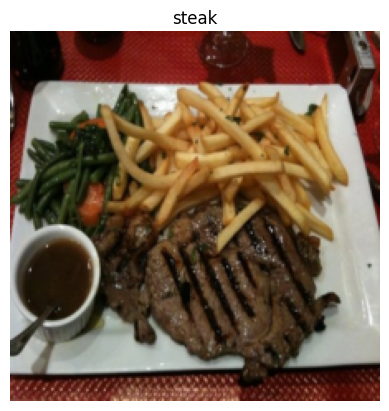

In [24]:
plt.imshow(image.permute(1, 2, 0)) 
plt.title(class_names[label])
plt.axis(False);
print(f"Original image shape: {image.shape}")

image_out_of_conv = conv2d(image.unsqueeze(0)) 
print(f"Image feature map shape: {image_out_of_conv.shape}")

image_out_of_conv_flattened = flatten(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

In [25]:
image_out_of_conv_flattened_reshaped = image_out_of_conv_flattened.permute(0, 2, 1) 
print(f"Patch embedding sequence shape: {image_out_of_conv_flattened_reshaped.shape} -> [batch_size, num_patches, embedding_size]")

Patch embedding sequence shape: torch.Size([1, 196, 768]) -> [batch_size, num_patches, embedding_size]


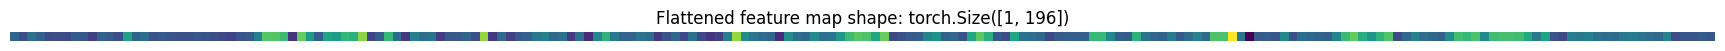

In [26]:
single_flattened_feature_map = image_out_of_conv_flattened_reshaped[:, :, 0] 

plt.figure(figsize=(22, 22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened feature map shape: {single_flattened_feature_map.shape}")
plt.axis(False);

In [27]:
single_flattened_feature_map, single_flattened_feature_map.requires_grad, single_flattened_feature_map.shape

(tensor([[ 4.1293e-02, -6.0372e-02,  1.0035e-01,  1.8534e-02, -7.0364e-02,
          -5.8982e-02, -6.6258e-02,  2.2028e-03, -1.7886e-02, -1.1571e-01,
           3.3370e-02, -1.0551e-02, -5.9646e-02,  3.4527e-01,  3.7433e-02,
           8.4490e-02, -4.3280e-02, -1.1699e-02, -4.0488e-02, -4.8167e-02,
          -4.3236e-02, -2.0787e-02, -3.9159e-02, -5.2851e-02, -7.9678e-02,
          -1.0236e-01, -3.0788e-02, -1.2459e-02,  1.6760e-01,  5.2397e-01,
           5.1992e-01,  4.6641e-01, -1.6359e-01,  5.5512e-01,  3.0822e-01,
           9.0717e-03,  3.4890e-01,  3.1181e-01,  4.4054e-01,  4.1492e-01,
           6.3083e-01, -9.3785e-02,  1.4313e-02,  4.4222e-01,  7.0303e-02,
          -1.4323e-01,  1.7386e-01,  7.8187e-02,  1.1862e-01, -1.2908e-01,
          -6.9014e-03, -9.5015e-03,  3.9930e-02, -5.0471e-02,  6.4934e-01,
          -1.4136e-01,  7.0483e-02, -1.0762e-01, -5.8000e-03,  2.1284e-02,
           1.2735e-01,  1.7635e-01,  5.3567e-02,  9.5435e-02, -1.2939e-01,
           9.6300e-02, -1

In [28]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels: int = 3, patch_size: int = 16, embedding_dim: int =768):
        super().__init__()

        self.patcher = nn.Conv2d(in_channels = in_channels, out_channels = embedding_dim, kernel_size = patch_size, stride = patch_size, padding = 0)
        self.flatten = nn.Flatten(start_dim = 2, end_dim = 3)
    
    def forward(self, x):
        image_resolution = x.shape[-1]
        assert image_resolution % patch_size == 0, f"Input image size must be divisible by patch size, image shape: {image_resolution}, patch size: {patch_size}"
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)
        return x_flattened.permute(0,2,1)
                 

In [29]:
set_seeds()

patchify = PatchEmbedding(in_channels=3,
                          patch_size=16,
                          embedding_dim=768)

print(f"Input image shape: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0)) 
print(f"Output patch embedding shape: {patch_embedded_image.shape}")

Input image shape: torch.Size([1, 3, 224, 224])


Output patch embedding shape: torch.Size([1, 196, 768])


In [30]:
random_input_image = (1, 3, 224, 224)
random_input_image_error = (1, 3, 250, 250)

In [31]:
print(patch_embedded_image)
print(f"Patch embedding shape: {patch_embedded_image.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[-4.9274e-02, -1.2501e-04, -3.5572e-02,  ...,  1.1833e-02,
          -1.2263e-02,  2.4581e-02],
         [-6.7786e-02,  5.7727e-02, -5.2555e-02,  ...,  1.9184e-02,
          -7.7774e-02,  8.0018e-03],
         [-1.4700e-01, -5.3285e-02, -3.3463e-02,  ...,  2.2622e-02,
          -6.2656e-02,  2.1706e-01],
         ...,
         [-2.5101e-01, -4.8923e-02, -3.0782e-02,  ...,  2.0408e-01,
          -1.1166e-01,  1.8546e-01],
         [-1.9574e-01, -3.1517e-02, -2.3149e-02,  ...,  4.5486e-02,
          -1.0676e-01,  1.2881e-01],
         [-3.2620e-01, -6.5398e-03, -8.1226e-03,  ...,  1.0947e-01,
          -1.3815e-01,  1.0507e-01]]], grad_fn=<PermuteBackward0>)
Patch embedding shape: torch.Size([1, 196, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [32]:
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]

class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension), 
                           requires_grad=True) 

print(class_token[:, :, :10])

print(f"Class token shape: {class_token.shape} -> [batch_size, number_of_tokens, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class token shape: torch.Size([1, 1, 768]) -> [batch_size, number_of_tokens, embedding_dimension]


In [33]:
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image),
                                                      dim=1) 

print(patch_embedded_image_with_class_embedding)
print(f"Sequence of patch embeddings with class token prepended shape: {patch_embedded_image_with_class_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[ 1.0000e+00,  1.0000e+00,  1.0000e+00,  ...,  1.0000e+00,
           1.0000e+00,  1.0000e+00],
         [-4.9274e-02, -1.2501e-04, -3.5572e-02,  ...,  1.1833e-02,
          -1.2263e-02,  2.4581e-02],
         [-6.7786e-02,  5.7727e-02, -5.2555e-02,  ...,  1.9184e-02,
          -7.7774e-02,  8.0018e-03],
         ...,
         [-2.5101e-01, -4.8923e-02, -3.0782e-02,  ...,  2.0408e-01,
          -1.1166e-01,  1.8546e-01],
         [-1.9574e-01, -3.1517e-02, -2.3149e-02,  ...,  4.5486e-02,
          -1.0676e-01,  1.2881e-01],
         [-3.2620e-01, -6.5398e-03, -8.1226e-03,  ...,  1.0947e-01,
          -1.3815e-01,  1.0507e-01]]], grad_fn=<CatBackward0>)
Sequence of patch embeddings with class token prepended shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [34]:
patch_embedded_image_with_class_embedding, patch_embedded_image_with_class_embedding.shape

(tensor([[[ 1.0000e+00,  1.0000e+00,  1.0000e+00,  ...,  1.0000e+00,
            1.0000e+00,  1.0000e+00],
          [-4.9274e-02, -1.2501e-04, -3.5572e-02,  ...,  1.1833e-02,
           -1.2263e-02,  2.4581e-02],
          [-6.7786e-02,  5.7727e-02, -5.2555e-02,  ...,  1.9184e-02,
           -7.7774e-02,  8.0018e-03],
          ...,
          [-2.5101e-01, -4.8923e-02, -3.0782e-02,  ...,  2.0408e-01,
           -1.1166e-01,  1.8546e-01],
          [-1.9574e-01, -3.1517e-02, -2.3149e-02,  ...,  4.5486e-02,
           -1.0676e-01,  1.2881e-01],
          [-3.2620e-01, -6.5398e-03, -8.1226e-03,  ...,  1.0947e-01,
           -1.3815e-01,  1.0507e-01]]], grad_fn=<CatBackward0>),
 torch.Size([1, 197, 768]))

In [35]:
number_of_patches = int((height * width) / patch_size**2)

embedding_dimension = patch_embedded_image_with_class_embedding.shape[2]

position_embedding = nn.Parameter(torch.ones(1,
                                             number_of_patches+1,
                                             embedding_dimension),
                                  requires_grad=True) 

print(position_embedding[:, :10, :10])
print(f"Position embedding shape: {position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Position embedding shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [36]:
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding
print(patch_and_position_embedding)
print(f"Patch embeddings, class token prepended and positional embeddings added shape: {patch_and_position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
         [0.9507, 0.9999, 0.9644,  ..., 1.0118, 0.9877, 1.0246],
         [0.9322, 1.0577, 0.9474,  ..., 1.0192, 0.9222, 1.0080],
         ...,
         [0.7490, 0.9511, 0.9692,  ..., 1.2041, 0.8883, 1.1855],
         [0.8043, 0.9685, 0.9769,  ..., 1.0455, 0.8932, 1.1288],
         [0.6738, 0.9935, 0.9919,  ..., 1.1095, 0.8619, 1.1051]]],
       grad_fn=<AddBackward0>)
Patch embeddings, class token prepended and positional embeddings added shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [37]:
set_seeds()

patch_size = 16

print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

x = image.unsqueeze(0)
print(f"Input image with batch dimension shape: {x.shape}")

patch_embedding_layer = PatchEmbedding(in_channels=3,
                                       patch_size=patch_size,
                                       embedding_dim=768)

patch_embedding = patch_embedding_layer(x)
print(f"Patching embedding shape: {patch_embedding.shape}")

batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad=True)
print(f"Class token embedding shape: {class_token.shape}")

patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Patch embedding with class token shape: {patch_embedding_class_token.shape}")

number_of_patches = int((height * width) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension),
                                  requires_grad=True)

patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")

Image tensor shape: torch.Size([3, 224, 224])
Input image with batch dimension shape: torch.Size([1, 3, 224, 224])
Patching embedding shape: torch.Size([1, 196, 768])
Class token embedding shape: torch.Size([1, 1, 768])
Patch embedding with class token shape: torch.Size([1, 197, 768])
Patch and position embedding shape: torch.Size([1, 197, 768])


In [38]:
class MultiheadSelfAttentionBlock(nn.Module):
    def __init__(self,
                 embedding_dim:int=768, 
                 num_heads:int=12,
                 attn_dropout:float=0): 
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        self.multihead_attn = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                    num_heads=num_heads,
                                                    dropout=attn_dropout,
                                                    batch_first=True)

    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, _ = self.multihead_attn(query=x, 
                                             key=x,
                                             value=x,
                                             need_weights=False) 
        return attn_output

In [39]:
multihead_self_attention_block = MultiheadSelfAttentionBlock(embedding_dim=768, 
                                                             num_heads=12) 

patched_image_through_msa_block = multihead_self_attention_block(patch_and_position_embedding)
print(f"Input shape of MSA block: {patch_and_position_embedding.shape}")
print(f"Output shape MSA block: {patched_image_through_msa_block.shape}")

Input shape of MSA block: torch.Size([1, 197, 768])
Output shape MSA block: torch.Size([1, 197, 768])


In [40]:
class MLPBlock(nn.Module):
    def __init__(self,
                 embedding_dim:int=768, 
                 mlp_size:int=3072, 
                 dropout:float=0.1): 
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim,
                      out_features=mlp_size),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size, 
                      out_features=embedding_dim), 
            nn.Dropout(p=dropout)
        )

    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        return x

In [41]:
mlp_block = MLPBlock(embedding_dim=768,
                     mlp_size=3072, 
                     dropout=0.1) 

patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
print(f"Input shape of MLP block: {patched_image_through_msa_block.shape}")
print(f"Output shape MLP block: {patched_image_through_mlp_block.shape}")

Input shape of MLP block: torch.Size([1, 197, 768])
Output shape MLP block: torch.Size([1, 197, 768])


In [42]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, 
                 embedding_dim: int = 768,
                 num_heads: int = 12,
                 mlp_size: int = 3072,
                 mlp_dropout:float = 0.1,
                 attn_dropout: float = 0):
        super().__init__()
        self.msa_block = MultiheadSelfAttentionBlock(embedding_dim = embedding_dim,
        num_heads = num_heads,
        attn_dropout = attn_dropout)

        self.mlp_block = MLPBlock(embedding_dim = embedding_dim,
                                  mlp_size = mlp_size,
                                  dropout = mlp_dropout)
    
    def forward(self, x):
        x = self.msa_block(x) + x
        x = self.mlp_block(x) + x
        return x


                 
    
        
    

In [43]:
transformer_encoder_block = TransformerEncoderBlock()

In [44]:
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=768, # Hidden size D from Table 1 for ViT-Base
                                                             nhead=12, # Heads from Table 1 for ViT-Base
                                                             dim_feedforward=3072, # MLP size from Table 1 for ViT-Base
                                                             dropout=0.1, # Amount of dropout for dense layers from Table 3 for ViT-Base
                                                             activation="gelu", # GELU non-linear activation
                                                             batch_first=True, # Do our batches come first?
                                                             norm_first=True) # Normalize first or after MSA/MLP layers?

torch_transformer_encoder_layer

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (linear1): Linear(in_features=768, out_features=3072, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=3072, out_features=768, bias=True)
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

In [45]:
summary(model=torch_transformer_encoder_layer,
        input_size=(1, 197, 768), 
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderLayer (TransformerEncoderLayer)  [1, 197, 768]        [1, 197, 768]        --                   True
├─LayerNorm (norm1)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─MultiheadAttention (self_attn)                   [1, 197, 768]        [1, 197, 768]        2,362,368            True
├─Dropout (dropout1)                               [1, 197, 768]        [1, 197, 768]        --                   --
├─LayerNorm (norm2)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─Linear (linear1)                                 [1, 197, 768]        [1, 197, 3072]       2,362,368            True
├─Dropout (dropout)                                [1, 197, 3072]       [1, 197, 3072]       --                   --
├─Linear (linear2)                             

In [46]:
class ViT(nn.Module):
    def __init__(self,
                 img_size=224,
                 in_channels=3,
                 patch_size=16,
                 num_transformer_layers=12,
                 embedding_dim=768,
                 mlp_size=3072,
                 num_heads=12,
                 attn_dropout=0,
                 mlp_dropout=0.1,
                 embedding_dropout=0.1,
                 num_classes=1000):
        super().__init__()

        assert img_size % patch_size == 0

        self.num_patches = (img_size * img_size) // patch_size**2

        self.class_embedding = nn.Parameter(
            torch.randn(1, 1, embedding_dim),
            requires_grad=True
        )

        self.position_embedding = nn.Parameter(
            torch.randn(1, self.num_patches + 1, embedding_dim),
            requires_grad=True
        )

        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        self.patch_embedding = PatchEmbedding(
            in_channels=in_channels,
            patch_size=patch_size,
            embedding_dim=embedding_dim
        )

        self.transformer_encoder = nn.Sequential(
            *[
                TransformerEncoderBlock(
                    embedding_dim=embedding_dim,
                    num_heads=num_heads,
                    mlp_size=mlp_size,
                    mlp_dropout=mlp_dropout
                )
                for _ in range(num_transformer_layers)
            ]
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, num_classes)
        )

    def forward(self, x):
        batch_size = x.shape[0]

        class_token = self.class_embedding.expand(batch_size, -1, -1)

        x = self.patch_embedding(x)

        x = torch.cat((class_token, x), dim=1)

        x = self.position_embedding + x

        x = self.embedding_dropout(x)

        x = self.transformer_encoder(x)

        x = self.classifier(x[:, 0])

        return x


In [47]:
batch_size = 32
class_token_embedding_single = nn.Parameter(data=torch.randn(1, 1, 768)) 
class_token_embedding_expanded = class_token_embedding_single.expand(batch_size, -1, -1)
print(f"Shape of class token embedding single: {class_token_embedding_single.shape}")
print(f"Shape of class token embedding expanded: {class_token_embedding_expanded.shape}")

Shape of class token embedding single: torch.Size([1, 1, 768])
Shape of class token embedding expanded: torch.Size([32, 1, 768])


In [48]:
set_seeds()

random_image_tensor = torch.randn(1, 3, 224, 224) 

vit = ViT(num_classes=len(class_names))

vit(random_image_tensor)

tensor([[0.2525, 0.8748, 1.2374]], grad_fn=<AddmmBackward0>)

In [ ]:
from torchinfo import summary

summary(model=vit,
        input_size=(32, 3, 224, 224), 
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                                    [32, 3, 224, 224]    [32, 3]              152,064              True
├─PatchEmbedding (patch_embedding)                           [32, 3, 224, 224]    [32, 196, 768]       --                   True
│    └─Conv2d (patcher)                                      [32, 3, 224, 224]    [32, 768, 14, 14]    590,592              True
│    └─Flatten (flatten)                                     [32, 768, 14, 14]    [32, 768, 196]       --                   --
├─Dropout (embedding_dropout)                                [32, 197, 768]       [32, 197, 768]       --                   --
├─Sequential (transformer_encoder)                           [32, 197, 768]       [32, 197, 768]       --                   True
│    └─TransformerEncoderBlock (0)                           [32, 197, 768]       [32, 197, 768]

: 

In [ ]:
from going_modular.going_modular import engine

optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=3e-3, 
                             betas=(0.9, 0.999),
                             weight_decay=0.3) 

loss_fn = torch.nn.CrossEntropyLoss()

set_seeds()

results = engine.train(model=vit,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=1,
                       device=device)

  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\prave\PyTorch\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
